<a href="https://colab.research.google.com/github/ValleyFarell/VAE-from-Scratch/blob/main/VariationalAutoencoder_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational Autoencoders

Implement a VAE in PyTorch, first on Two Moons and then on MNIST. Inspect training
losses, reconstructions, prior samples, and latent representations.

Run the cells in order. A GPU is recommended for MNIST. All networks train from
scratch; the notebook does not require checkpoints from the diffusion examples.

## The VAE Objective

The encoder defines a diagonal Gaussian approximate posterior:

$$q_\phi(z\mid x)=\mathcal N\left(\mu_\phi(x),\operatorname{diag}(\exp(\ell_\phi(x)))\right),
\qquad p(z)=\mathcal N(0,I).$$

Here `logvar` represents $\ell=\log\sigma^2$. The reparameterization trick makes
latent sampling differentiable with respect to the encoder parameters:

$$z=\mu_\phi(x)+\exp(\ell_\phi(x)/2)\odot\varepsilon,
\qquad\varepsilon\sim\mathcal N(0,I).$$

Minimize the negative evidence lower bound (ELBO):

$$L=\mathbb E_{q_\phi(z\mid x)}[-\log p_\theta(x\mid z)]
+D_{KL}(q_\phi(z\mid x)\|p(z)),$$

$$D_{KL}=\frac12\sum_j\left(\mu_j^2+\exp(\ell_j)-1-\ell_j\right).$$

Use one posterior sample per example to estimate the reconstruction expectation.
Sum over observation dimensions for reconstruction and latent dimensions for KL,
then average over the batch. The KL coefficient is **1**, with no warm-up or
additional loss reweighting.

Generation samples $z\sim\mathcal N(0,I)$ and then $x\sim p_\theta(x\mid z)$.
No ODE or SDE integration is needed.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import make_moons
from torch import nn
from torchvision.datasets import MNIST

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name)
    print(f"GPU memory: {props.total_memory / 1024**3:.1f} GiB")


PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
GPU memory: 14.6 GiB


## Two Moons

Standardize the training data and reuse its mean and standard deviation for the
held-out data. The latent dimension is 2. Use a Gaussian observation model with
fixed standard deviation $\sigma_x=0.1$ in standardized coordinates:

$$p_\theta(x\mid z)=\mathcal N(f_\theta(z),\sigma_x^2 I),$$

$$-\log p_\theta(x\mid z)=\sum_i\left[
\frac{(x_i-f_\theta(z)_i)^2}{2\sigma_x^2}+\log\sigma_x+\frac12\log(2\pi)\right].$$

The Gaussian normalization constant is included. A continuous-density negative
log-likelihood can be negative; this alone does not indicate an error.

In [ ]:
train_raw, train_labels = make_moons(
    n_samples=20_000,
    noise=0.05,
    random_state=SEED,
)
test_raw, test_labels = make_moons(
    n_samples=4_000,
    noise=0.05,
    random_state=SEED + 1,
)

mean = train_raw.mean(axis=0, keepdims=True)
std = train_raw.std(axis=0, keepdims=True)

train_np = ((train_raw - mean) / std).astype(np.float32)
test_np = ((test_raw - mean) / std).astype(np.float32)

train_data = torch.from_numpy(train_np)
test_data = torch.from_numpy(test_np)

print("Train:", train_data.shape)
print("Test:", test_data.shape)


Train: torch.Size([20000, 2])
Test: torch.Size([4000, 2])


In [ ]:
class VAENeuralNetwork(nn.Module):
    def __init__(self, dim=2, latent_dim=2, hidden_dims=(128, 128)):
        super().__init__()

        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(dim, hidden_dims[0]),
            nn.SiLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.SiLU(),
        )
        self.mean = nn.Linear(hidden_dims[1], latent_dim)
        self.logvar = nn.Linear(hidden_dims[1], latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims[1]),
            nn.SiLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.SiLU(),
            nn.Linear(hidden_dims[0], dim),
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.mean(x), self.logvar(x)

    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        epsilons = torch.randn_like(std)
        return mean + std * epsilons

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        return self.decode(z), mean, logvar


class VAEModel:
    def __init__(
        self,
        NN,
        dim,
        dataset,
        likelihood="gaussian",
        observation_std=0.1,
        verbose=True,
        log_every=50,
    ):
        if likelihood not in ("gaussian", "bernoulli"):
            raise ValueError("likelihood must be gaussian or bernoulli.")
        if observation_std <= 0 or log_every < 1:
            raise ValueError("observation_std and log_every must be positive.")

        self.NN = NN
        self.dim = dim
        self.dataset = dataset
        self.likelihood = likelihood
        self.observation_std = observation_std
        self.verbose = verbose
        self.log_every = log_every
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.NN.to(self.device)

    def loss(self, inputs, decoded, mean, logvar):
        if self.likelihood == "bernoulli":
            reconstruction = F.binary_cross_entropy_with_logits(
                decoded, inputs, reduction="none"
            ).sum(dim=1)
        else:
            reconstruction = (
                0.5 * ((inputs - decoded) / self.observation_std) ** 2
                + math.log(self.observation_std)
                + 0.5 * math.log(2 * math.pi)
            ).sum(dim=1)

        kl = -0.5 * (1 + logvar - mean.square() - logvar.exp()).sum(dim=1)
        return (reconstruction + kl).mean(), reconstruction.mean(), kl.mean()

    def fit(self, epochs, batch_size, learning_rate=0.001, binarize=False):
        if epochs < 1 or batch_size < 1 or len(self.dataset) == 0:
            raise ValueError("epochs, batch_size, and dataset size must be positive.")
        if binarize and self.likelihood != "bernoulli":
            raise ValueError("Binarization requires a Bernoulli observation model.")

        self.NN.to(self.device)
        dtype = next(self.NN.parameters()).dtype
        train_loader = torch.utils.data.DataLoader(
            self.dataset, batch_size=batch_size, shuffle=True
        )
        optimizer = optim.Adam(self.NN.parameters(), lr=learning_rate)
        history = {"loss": [], "reconstruction": [], "kl": []}

        for epoch in range(epochs):
            self.NN.train()
            running = np.zeros(3)
            seen_samples = 0

            for inputs in train_loader:
                inputs = inputs.to(device=self.device, dtype=dtype)
                if binarize:
                    inputs = torch.bernoulli(inputs)

                optimizer.zero_grad(set_to_none=True)
                decoded, mean, logvar = self.NN(inputs)
                loss, reconstruction, kl = self.loss(inputs, decoded, mean, logvar)
                if not torch.isfinite(loss):
                    raise ValueError("NaN or Inf encountered during training.")
                loss.backward()
                optimizer.step()

                running += np.array(
                    [loss.item(), reconstruction.item(), kl.item()]
                ) * len(inputs)
                seen_samples += len(inputs)

            values = running / seen_samples
            for key, value in zip(history, values):
                history[key].append(float(value))

            if self.verbose and (
                epoch == 0 or (epoch + 1) % self.log_every == 0 or epoch + 1 == epochs
            ):
                print(
                    f"Epoch {epoch + 1}/{epochs}, loss: {values[0]:.4f}, "
                    f"reconstruction: {values[1]:.4f}, KL: {values[2]:.4f}"
                )

        return history

    @torch.no_grad()
    def evaluate(self, dataset, batch_size=256):
        if len(dataset) == 0 or batch_size < 1:
            raise ValueError("dataset size and batch_size must be positive.")
        self.NN.eval()
        dtype = next(self.NN.parameters()).dtype
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        running = np.zeros(3)
        seen_samples = 0

        for inputs in loader:
            inputs = inputs.to(device=self.device, dtype=dtype)
            decoded, mean, logvar = self.NN(inputs)
            values = self.loss(inputs, decoded, mean, logvar)
            running += np.array([value.item() for value in values]) * len(inputs)
            seen_samples += len(inputs)

        return dict(zip(("loss", "reconstruction", "kl"), running / seen_samples))

    def observation_mean(self, decoded):
        if self.likelihood == "bernoulli":
            return torch.sigmoid(decoded)
        return decoded

    @torch.no_grad()
    def reconstruct(self, inputs, sample_latent=False):
        self.NN.eval()
        dtype = next(self.NN.parameters()).dtype
        inputs = inputs.to(device=self.device, dtype=dtype)
        mean, logvar = self.NN.encode(inputs)
        z = self.NN.reparameterize(mean, logvar) if sample_latent else mean
        return self.observation_mean(self.NN.decode(z))

    @torch.no_grad()
    def sample(self, n_samples=1, sample_observation=True):
        if n_samples < 1:
            raise ValueError("n_samples must be positive.")
        self.NN.eval()
        dtype = next(self.NN.parameters()).dtype
        z = torch.randn(n_samples, self.NN.latent_dim, device=self.device, dtype=dtype)
        mean = self.observation_mean(self.NN.decode(z))
        if not sample_observation:
            return mean
        if self.likelihood == "bernoulli":
            return torch.bernoulli(mean)
        return mean + self.observation_std * torch.randn_like(mean)


In [ ]:
torch.manual_seed(SEED)

vae_net = VAENeuralNetwork()
vae_model = VAEModel(vae_net, 2, train_data, log_every=25)
vae_history = vae_model.fit(100, 256)

torch.manual_seed(123)
print("Held-out negative ELBO:", vae_model.evaluate(test_data))


Epoch 1/100, loss: 26.9136, reconstruction: 22.8176, KL: 4.0959
Epoch 25/100, loss: 2.2590, reconstruction: -1.7477, KL: 4.0067
Epoch 50/100, loss: 2.0985, reconstruction: -1.7688, KL: 3.8673
Epoch 75/100, loss: 2.0295, reconstruction: -1.8048, KL: 3.8343
Epoch 100/100, loss: 1.9300, reconstruction: -1.8522, KL: 3.7822
Held-out negative ELBO: {'loss': np.float64(1.9415867347717286), 'reconstruction': np.float64(-1.7622724628448487), 'kl': np.float64(3.7038591651916506)}


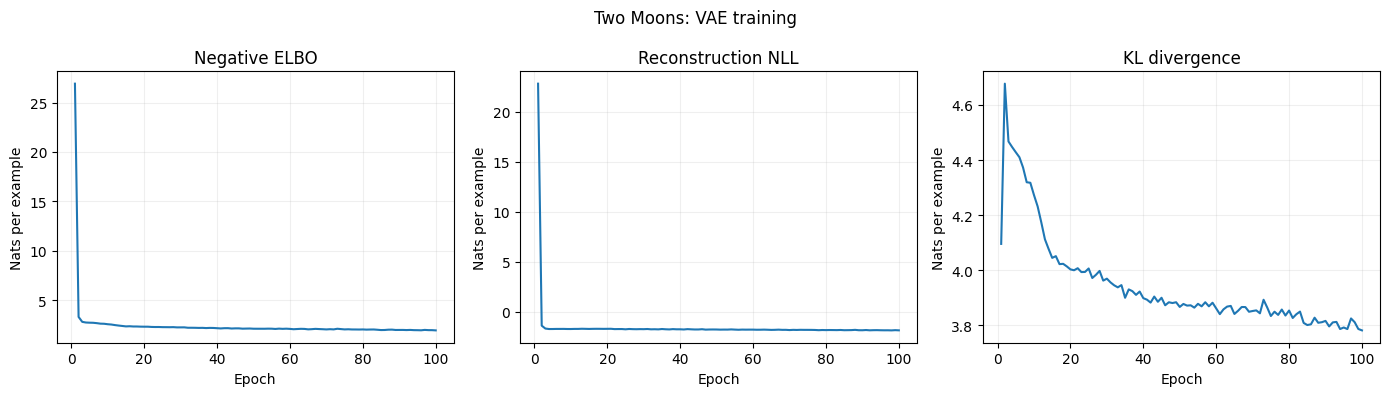

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, key, label in zip(
        axes,
        ["loss", "reconstruction", "kl"],
        ["Negative ELBO", "Reconstruction NLL", "KL divergence"],
    ):
        ax.plot(range(1, len(history[key]) + 1), history[key])
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Nats per example")
        ax.grid(alpha=0.2)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_history(vae_history, "Two Moons: VAE training")


### Reconstructions and Prior Samples

Reconstructions decode the posterior mean, `decode(mu)`, for reproducible plots.
This is a visualization convention, not the exact posterior predictive mean.
Generated points include Gaussian observation noise and are sampled independently
of the held-out inputs.

Prior samples may fill the gap between the moons even when reconstructions are
accurate. The two plots assess different properties of the learned model.

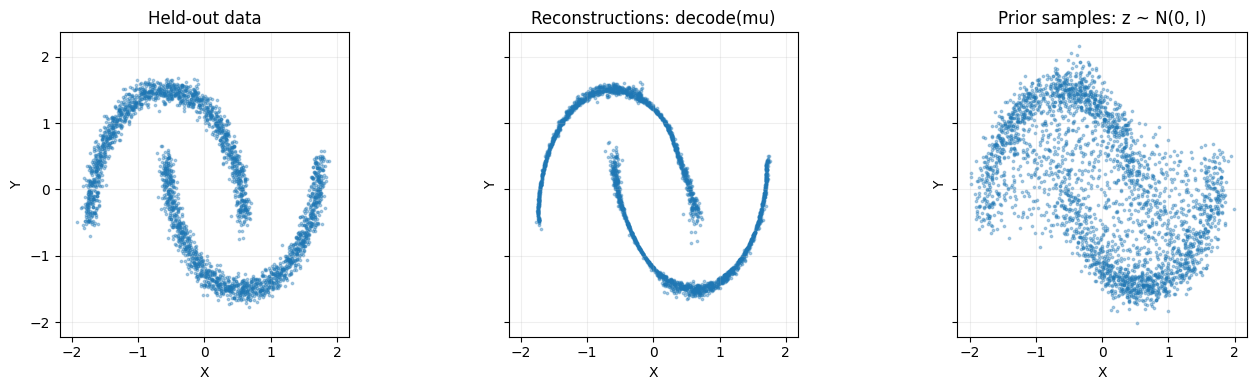

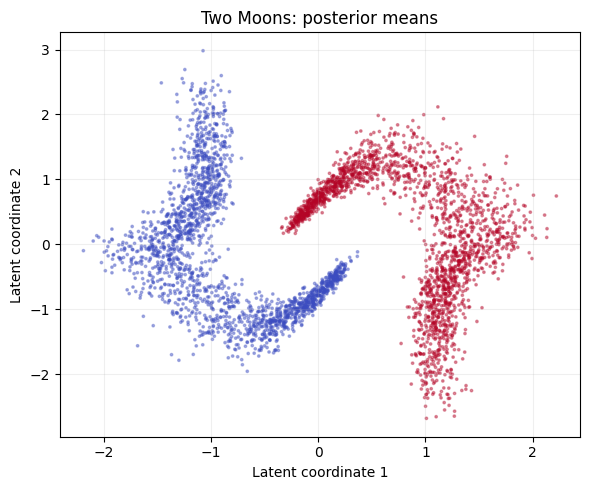

In [ ]:
torch.manual_seed(123)
reconstructed = vae_model.reconstruct(test_data[:3_000]).cpu().numpy()
generated = vae_model.sample(3_000).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)

for ax, points, title in zip(
    axes,
    [test_np[:3_000], reconstructed, generated],
    ["Held-out data", "Reconstructions: decode(mu)", "Prior samples: z ~ N(0, I)"],
):
    ax.scatter(points[:, 0], points[:, 1], s=3, alpha=0.35)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


with torch.no_grad():
    latent_mean, _ = vae_model.NN.encode(test_data.to(vae_model.device))
    latent_mean = latent_mean.cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    latent_mean[:, 0], latent_mean[:, 1], c=test_labels, cmap="coolwarm", s=3, alpha=0.4
)
ax.set_title("Two Moons: posterior means")
ax.set_xlabel("Latent coordinate 1")
ax.set_ylabel("Latent coordinate 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## MNIST

Use a 16-dimensional latent space and a Bernoulli observation model:

$$p_\theta(x\mid z)=\prod_i\operatorname{Bernoulli}(x_i;\operatorname{sigmoid}(a_\theta(z)_i)).$$

The decoder returns **logits**. `binary_cross_entropy_with_logits` computes the
reconstruction negative log-likelihood stably; do not apply a sigmoid before it.

Scale the original grayscale images to `[0, 1]` and dynamically binarize each
training batch using `torch.bernoulli`. This makes the targets binary, matching
the Bernoulli likelihood. The test split is binarized once with a fixed seed.
No class labels are used for training; they are used only to color the latent plot.

This observation model differs from the Gaussian example in the lecture notes;
the encoder, reparameterization trick, and standard ELBO objective are unchanged.

In [ ]:
mnist = MNIST(root="./data", train=True, download=True)
mnist_test = MNIST(root="./data", train=False, download=True)

mnist_train_data = mnist.data.reshape(-1, 28 * 28).to(torch.float32).div(255.0)
mnist_test_probabilities = (
    mnist_test.data.reshape(-1, 28 * 28).to(torch.float32).div(255.0)
)

generator = torch.Generator().manual_seed(123)
mnist_test_data = torch.bernoulli(mnist_test_probabilities, generator=generator)

print("Train:", mnist_train_data.shape)
print("Test:", mnist_test_data.shape)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.15MB/s]


Train: torch.Size([60000, 784])
Test: torch.Size([10000, 784])


Epoch 1/20, loss: 206.7703, reconstruction: 200.7782, KL: 5.9921
Epoch 2/20, loss: 144.6629, reconstruction: 132.9983, KL: 11.6646
Epoch 3/20, loss: 127.7587, reconstruction: 114.0470, KL: 13.7116
Epoch 4/20, loss: 118.8371, reconstruction: 103.4427, KL: 15.3944
Epoch 5/20, loss: 114.0415, reconstruction: 97.7974, KL: 16.2441
Epoch 6/20, loss: 110.6259, reconstruction: 93.5205, KL: 17.1055
Epoch 7/20, loss: 108.2275, reconstruction: 90.6042, KL: 17.6233
Epoch 8/20, loss: 106.1835, reconstruction: 88.0146, KL: 18.1689
Epoch 9/20, loss: 104.5673, reconstruction: 85.9604, KL: 18.6069
Epoch 10/20, loss: 103.4094, reconstruction: 84.5366, KL: 18.8728
Epoch 11/20, loss: 102.4707, reconstruction: 83.3817, KL: 19.0890
Epoch 12/20, loss: 101.6511, reconstruction: 82.4154, KL: 19.2356
Epoch 13/20, loss: 101.0157, reconstruction: 81.6794, KL: 19.3363
Epoch 14/20, loss: 100.3656, reconstruction: 80.8918, KL: 19.4738
Epoch 15/20, loss: 99.8501, reconstruction: 80.2812, KL: 19.5689
Epoch 16/20, loss

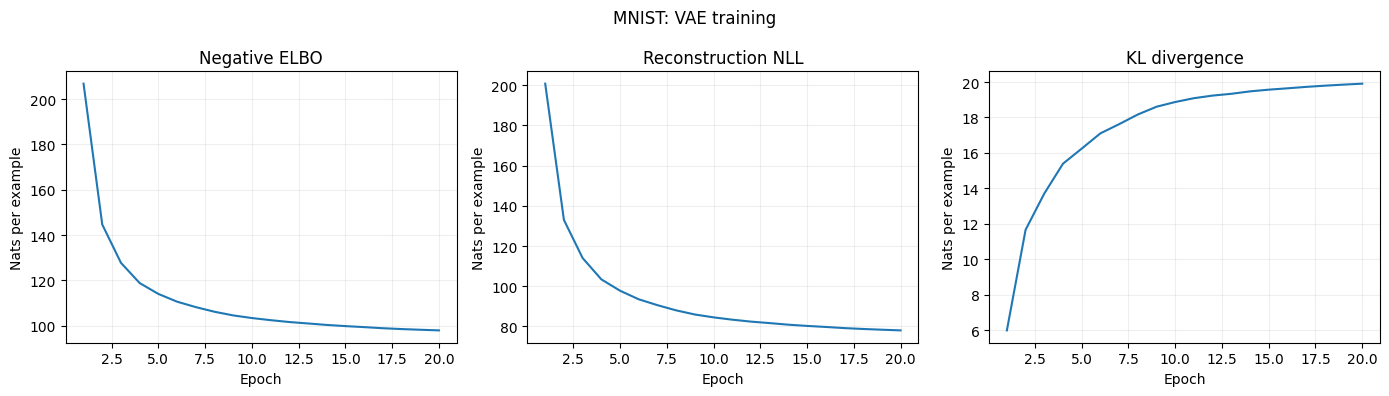

In [ ]:
class MNISTVAENetwork(VAENeuralNetwork):
    def __init__(self):
        super().__init__(dim=784, latent_dim=16, hidden_dims=(512, 256))


torch.manual_seed(SEED)

mnist_net = MNISTVAENetwork()
mnist_model = VAEModel(
    NN=mnist_net,
    dim=784,
    dataset=mnist_train_data,
    likelihood="bernoulli",
    log_every=1,
)

mnist_history = mnist_model.fit(
    epochs=20,
    batch_size=256,
    learning_rate=1e-3,
    binarize=True,
)

torch.manual_seed(123)
mnist_test_metrics = mnist_model.evaluate(mnist_test_data)
print("Held-out negative ELBO:", mnist_test_metrics)

plot_history(mnist_history, "MNIST: VAE training")


### Held-out Reconstructions

The top row contains fixed binarized test images. The bottom row shows decoder
probabilities obtained from their posterior means. These are reconstructions,
not unconditional generations.

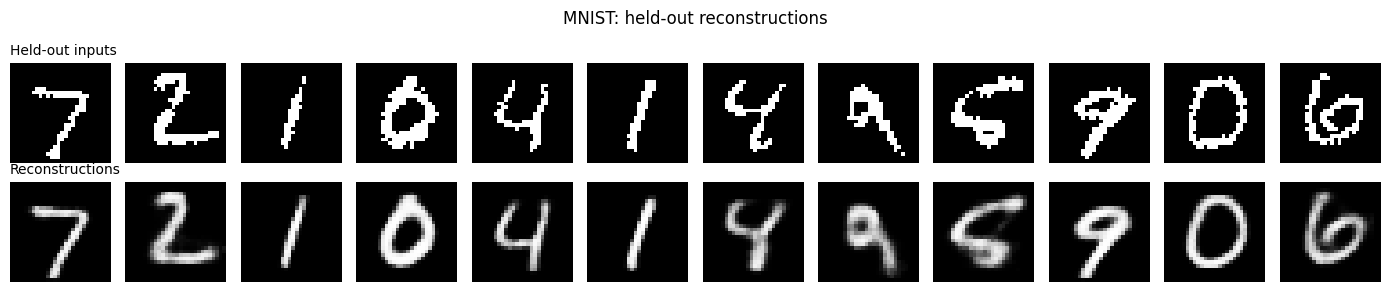

In [ ]:
mnist_reconstructed = mnist_model.reconstruct(mnist_test_data[:12]).cpu()

fig, axes = plt.subplots(2, 12, figsize=(14, 3))
for row, images, title in zip(
    axes,
    [mnist_test_data[:12], mnist_reconstructed],
    ["Held-out inputs", "Reconstructions"],
):
    for ax, pixels in zip(row, images):
        ax.imshow(pixels.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    row[0].set_title(title, loc="left", fontsize=10)

fig.suptitle("MNIST: held-out reconstructions")
plt.tight_layout()
plt.show()


### Generation from the Prior

Sample new latent vectors from `N(0, I)`. Display both decoder probabilities and
actual Bernoulli samples from those same probabilities. Probability images are
conditional means and are often smoother than sampled binary observations.
All examples use a fixed seed; none are selected for visual quality.

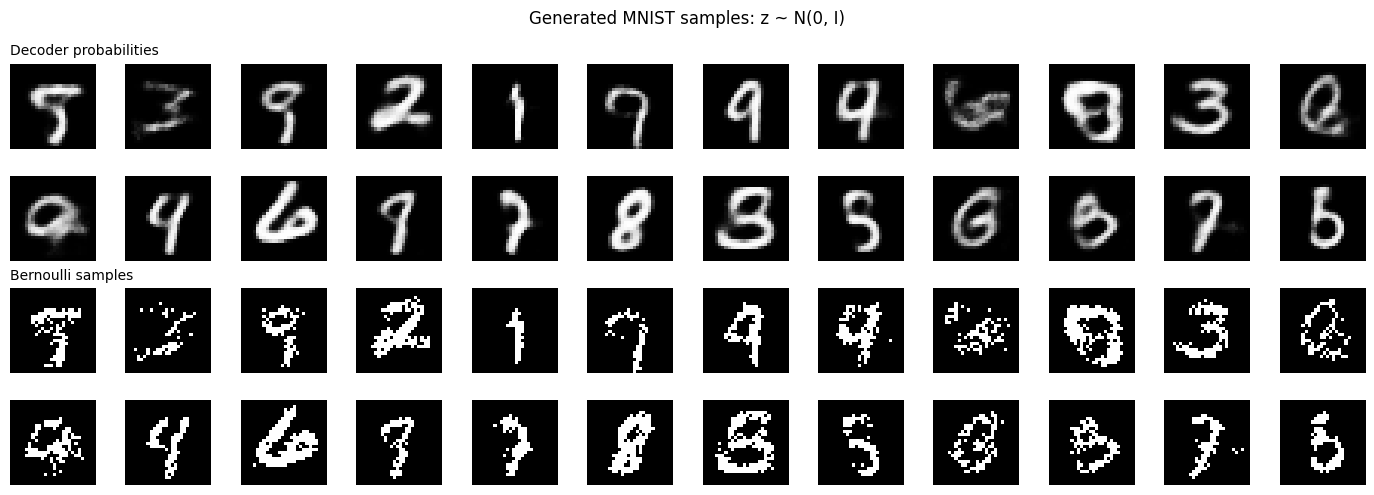

In [ ]:
torch.manual_seed(123)
mnist_probabilities = mnist_model.sample(24, sample_observation=False)
mnist_samples = torch.bernoulli(mnist_probabilities)

fig, axes = plt.subplots(4, 12, figsize=(14, 5))
for rows, images, title in zip(
    [axes[:2], axes[2:]],
    [mnist_probabilities.cpu(), mnist_samples.cpu()],
    ["Decoder probabilities", "Bernoulli samples"],
):
    for ax, pixels in zip(rows.flat, images):
        ax.imshow(pixels.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    rows[0, 0].set_title(title, loc="left", fontsize=10)

fig.suptitle("Generated MNIST samples: z ~ N(0, I)")
plt.tight_layout()
plt.show()


### Latent Representations and Interpolation

Plot the first two coordinates of the 16-dimensional posterior means. This is
only a coordinate projection, not the full latent space or a learned 2D embedding.
For interpolation, linearly interpolate all 16 coordinates between two held-out
posterior means and display the decoder probabilities.

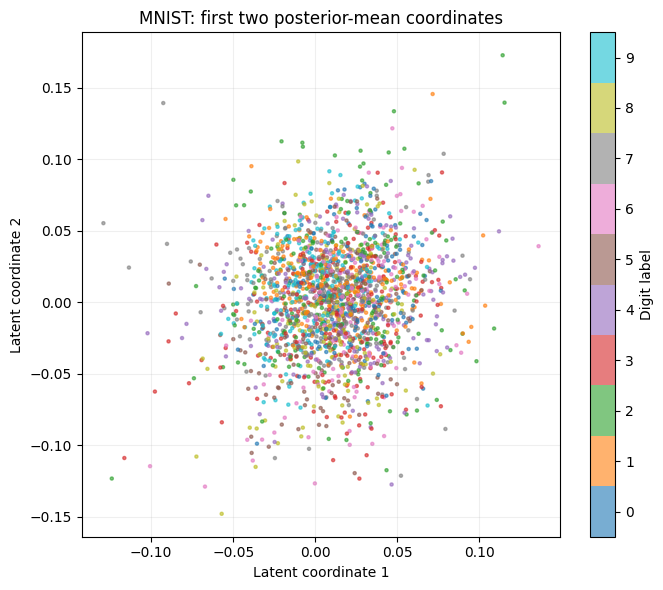

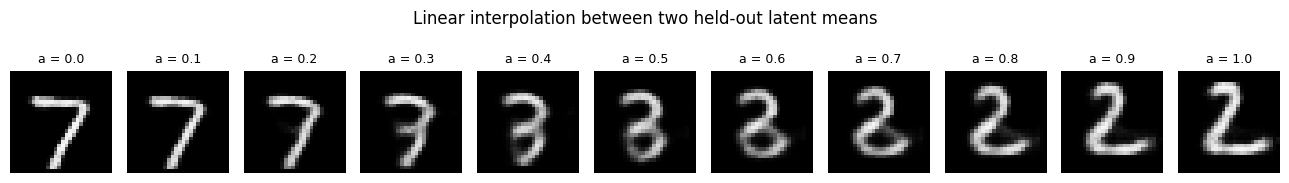

In [ ]:
with torch.no_grad():
    latent_mean, _ = mnist_model.NN.encode(
        mnist_test_data[:2_000].to(mnist_model.device)
    )
    latent_plot = latent_mean.cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 6))
points = ax.scatter(
    latent_plot[:, 0],
    latent_plot[:, 1],
    c=mnist_test.targets[:2_000].numpy(),
    cmap="tab10",
    vmin=-0.5,
    vmax=9.5,
    s=5,
    alpha=0.6,
)
fig.colorbar(points, ax=ax, ticks=range(10), label="Digit label")
ax.set_title("MNIST: first two posterior-mean coordinates")
ax.set_xlabel("Latent coordinate 1")
ax.set_ylabel("Latent coordinate 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


with torch.no_grad():
    weights = torch.linspace(0, 1, 11, device=mnist_model.device)[:, None]
    latents = (1 - weights) * latent_mean[0] + weights * latent_mean[1]
    interpolated = mnist_model.observation_mean(mnist_model.NN.decode(latents)).cpu()

fig, axes = plt.subplots(1, 11, figsize=(13, 2))
for ax, pixels, weight in zip(axes, interpolated, weights.cpu().flatten()):
    ax.imshow(pixels.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"a = {weight.item():.1f}", fontsize=9)
    ax.axis("off")

fig.suptitle("Linear interpolation between two held-out latent means")
plt.tight_layout()
plt.show()


## Sources

- [An Introduction to Flow Matching and Diffusion Models](https://diffusion.csail.mit.edu/),
  MIT lecture notes, Section 6.2 and the appendix discussion of the ELBO.
- Diederik P. Kingma and Max Welling,
  [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114).

The architectures and plotting code are educational implementations. A finite
training loss or a small reconstruction error alone does not establish good
prior-sample quality; inspect reconstructions and independent generations separately.

## Execution and Validation

All code cells were executed on CPU. Two Moons was trained for 100 epochs on
20,000 points; MNIST was trained for 20 epochs on all 60,000 training images.
Evaluation used all 10,000 fixed-binarized MNIST test images.

The held-out MNIST negative ELBO estimate was **97.91 nats per image**
(reconstruction NLL: 77.48; KL: 20.43).
This uses one posterior sample per test image and is not an exact log-likelihood.

Gaussian and Bernoulli reconstruction losses and the analytic KL were checked
against `torch.distributions`. Encoder and decoder gradients were finite and
nonzero. All displayed generations use fixed seeds without selecting favorable samples.
The figures are execution results, not illustrations.